Cell 1: Imports & Setup

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


Cell 2: Data Loading

In [31]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
test_dataset  = datasets.EMNIST(root='./data', split='balanced', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Data loaded successfully")

Data loaded successfully


Cell 3: Model Definition

In [32]:
class EMNISTModel(nn.Module):
    def __init__(self):
        super(EMNISTModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 47)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)

model = EMNISTModel().to(device)
print(model)

EMNISTModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=47, bias=True)
  )
)


Cell 4: Loss & Optimizer

In [33]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Cell 5: Training

In [34]:
for epoch in range(1):  
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 1.0821


Cell 6: Prediction & Visualization

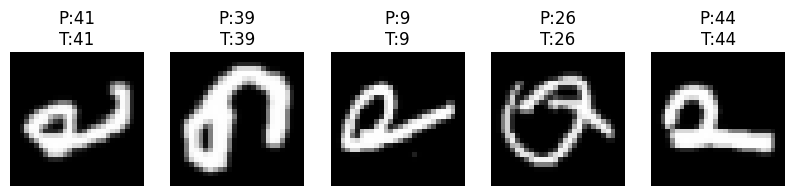

Sample Predictions:
Image 1: Predicted = 41, Actual = 41
Image 2: Predicted = 39, Actual = 39
Image 3: Predicted = 9, Actual = 9
Image 4: Predicted = 26, Actual = 26
Image 5: Predicted = 44, Actual = 44


In [35]:
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"P:{preds[i].item()}\nT:{labels[i].item()}")
    plt.axis('off')

plt.show()

print("Sample Predictions:")
for i in range(5):
    print(f"Image {i+1}: Predicted = {preds[i].item()}, Actual = {labels[i].item()}")

**Task#2**

Device: cpu
Classes: ['Abiu fruit', 'Acerola fruit', 'Ackee fruit', 'African Cherry Orange fruit', 'Akebi fruit', 'American Mayapple fruit', 'Apple fruit', 'Apricot fruit', 'Araza fruit', 'Avocado fruit', 'Açaí fruit', 'Banana fruit', 'Bilberry fruit', 'Black sapote fruit', 'Blackberry fruit', 'Blackcurrant fruit', 'Blueberry fruit', 'Boysenberry fruit', 'Breadfruit fruit', "Buddha's hand fruit", 'Cactus pear fruit', 'Canistel fruit', 'Cantaloupe fruit', 'Cashew fruit', 'Cempedak fruit', 'Cherimoya fruit', 'Cherry fruit', 'Chico fruit fruit', 'Clementine fruit', 'Cloudberry fruit', 'Coconut fruit', 'Crab apple fruit', 'Cranberry fruit', 'Currant fruit', 'Damson fruit', 'Dragonfruit  fruit', 'Durian fruit', 'Egg Fruit fruit', 'Elderberry fruit', 'Feijoa fruit', 'Finger Lime fruit', 'Goji berry fruit', 'Gooseberry fruit', 'Grape fruit', 'Grapefruit fruit', 'Guava fruit', 'Honeyberry fruit', 'Honeydew fruit', 'Huckleberry fruit', 'Jabuticaba fruit', 'Jackfruit fruit', 'Japanese plum fruit

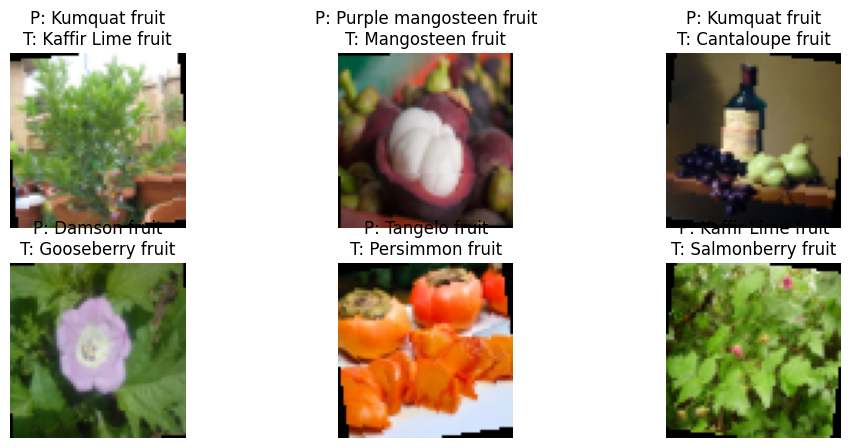


Sample Predictions:

Image 1: Predicted = Kumquat fruit, Actual = Kaffir Lime fruit
Image 2: Predicted = Purple mangosteen fruit, Actual = Mangosteen fruit
Image 3: Predicted = Kumquat fruit, Actual = Cantaloupe fruit
Image 4: Predicted = Damson fruit, Actual = Gooseberry fruit
Image 5: Predicted = Tangelo fruit, Actual = Persimmon fruit
Image 6: Predicted = Kaffir Lime fruit, Actual = Salmonberry fruit


In [36]:
# =========================
# FRUIT CLASSIFICATION CNN (WITH EARLY STOPPING)
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Dataset path
data_path = "/kaggle/input/datasets/rijudhara/list-of-fruits-images/images"

# Transform
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

# Dataset
dataset = datasets.ImageFolder(root=data_path, transform=transform)
classes = dataset.classes
print("Classes:", classes)

# Split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# CNN Model
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CNNModel(len(classes)).to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# =========================
# EARLY STOPPING SETUP
# =========================
patience = 5
best_loss = float("inf")
counter = 0

best_model_path = "best_model.pth"

# Training
epochs = 120

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    # -------------------------
    # EARLY STOPPING LOGIC
    # -------------------------
    if avg_loss < best_loss:
        best_loss = avg_loss
        counter = 0
        torch.save(model.state_dict(), best_model_path)
        print("✅ Model improved and saved!")
    else:
        counter += 1
        print(f"⚠ No improvement counter: {counter}/{patience}")

    if counter >= patience:
        print("⛔ Early stopping triggered!")
        break

# Load best model
model.load_state_dict(torch.load(best_model_path))

# =========================
# PREDICTION
# =========================
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()

# Display
plt.figure(figsize=(12,5))

for i in range(6):
    plt.subplot(2,3,i+1)

    img = images[i].permute(1,2,0).numpy()
    img = (img * 0.5) + 0.5

    plt.imshow(img)
    plt.title(f"P: {classes[preds[i]]}\nT: {classes[labels[i]]}")
    plt.axis('off')

plt.show()

# Output
print("\nSample Predictions:\n")

for i in range(6):
    print(f"Image {i+1}: Predicted = {classes[preds[i]]}, Actual = {classes[labels[i]]}")